In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sphviewer2
import h5py
import time

# Load the CAMELS TNG snapshot
# You can download this file from here:
# https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG/1P/1P_p11_2/snapshot_090.hdf5
file_path = './snapshot_090.hdf5'
print(f"Loading data from {file_path}...")

with h5py.File(file_path, 'r') as snap:
    # Read Gas Coordinates (x, y, z) and convert to float64
    pos_gas = snap['PartType1/Coordinates'][()]
    x = pos_gas[:, 0]
    y = pos_gas[:, 1]
    z = pos_gas[:, 2]
    
    # Read Gas Masses
    m = snap['Header'].attrs['MassTable'][1] * np.ones(len(x)) * 1e10  # Convert to M_sun/h
    
    # Read Box Size from Header
    Lbox = snap['Header'].attrs['BoxSize']
    
print(f"Loaded {len(x):,} gas particles.")
print(f"Box Size: {Lbox:.2f} ckpc/h")

Loading data from ./snapshot_090.hdf5...
Loaded 16,777,216 gas particles.
Box Size: 25000.00 ckpc/h


In [2]:
# =============================================================================
# Nearest-Neighbor Smoothing (K=32)
# =============================================================================

print("Calculating exact smoothing lengths (h)...")
t0 = time.time()
# The C++ backend handles the periodic boundary wrapping automatically
h = sphviewer2.estimate_h(x, y, z, Lbox=Lbox, k=32, num_threads=8)
print(f"Done in {time.time() - t0:.2f} seconds.")

Calculating exact smoothing lengths (h)...
Done in 138.63 seconds.


In [3]:
# You can get the file from https://users.flatironinstitute.org/~camels/Sims/IllustrisTNG/1P/1P_p11_2/groups_090.hdf5
groups_path = "./groups_090.hdf5"

print(f"Loading data from {groups_path}...")
with h5py.File(groups_path, 'r') as snap:
    # Read Group Coordinates
    GroupFirstSub = snap['Group/GroupFirstSub'][()]
    GroupCM = snap['Group/GroupCM'][()]
    Group_R_Crit200 = snap['Group/Group_R_Crit200'][()]
    SubhaloPos = snap['Subhalo/SubhaloPos'][()]

print(f"Loaded {len(GroupCM):,} Groups and {len(SubhaloPos):,} Subhalos")


Loading data from ./groups_090.hdf5...
Loaded 20,457 Groups and 18,408 Subhalos


Rendering frames...
Rendered frame 0 / 120
Rendered frame 0 / 120
Rendered frame 0 / 120
Rendered frame 0 / 120
Rendered frame 10 / 120
Rendered frame 20 / 120
Rendered frame 30 / 120
Rendered frame 40 / 120
Rendered frame 50 / 120
Rendered frame 60 / 120
Rendered frame 70 / 120
Rendered frame 80 / 120
Rendered frame 90 / 120
Rendered frame 100 / 120
Rendered frame 110 / 120

Success! Animation saved as 'flight.mp4'


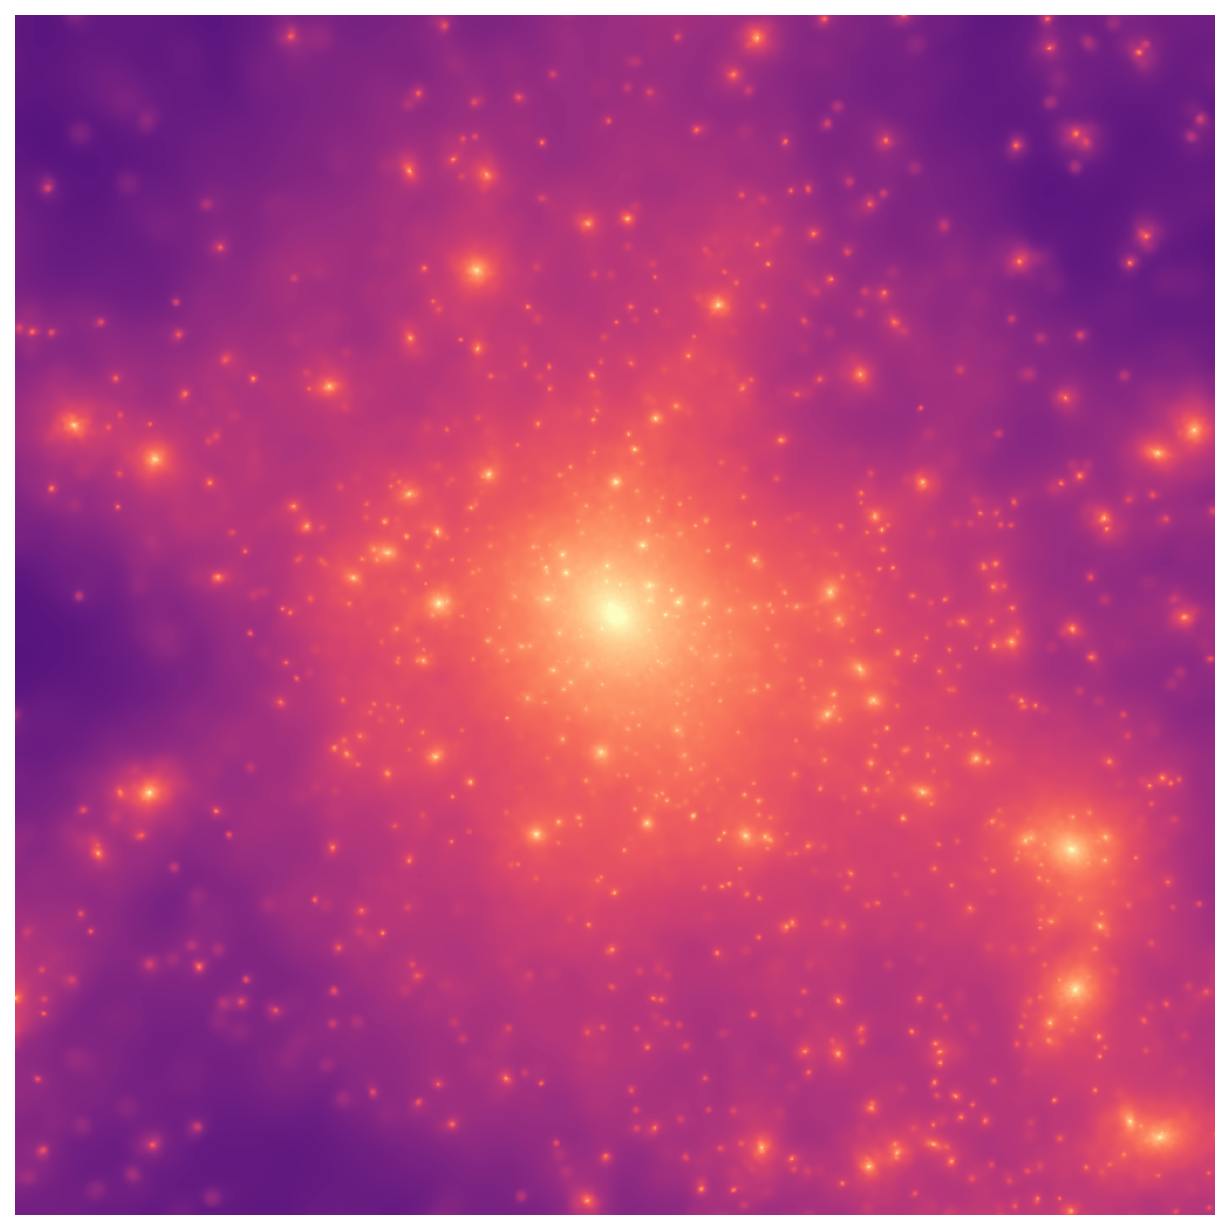

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

parts = sphviewer2.Particles(x, y, z, h, m)

# --- Animation Settings ---
n_frames = 120  # 4 seconds of video at 30 FPS
group_id = 0    # Target the most massive halo

# --- Target Camera Properties (The Halo) ---
target_xc = SubhaloPos[GroupFirstSub[group_id], 0]
target_yc = SubhaloPos[GroupFirstSub[group_id], 1]
target_zc = SubhaloPos[GroupFirstSub[group_id], 2]
target_extent = Group_R_Crit200[group_id] * 5.0 # Zoomed in nicely

# --- Initial Camera Properties (The Full Box) ---
start_xc = Lbox / 2.0
start_yc = Lbox / 2.0
start_zc = Lbox / 2.0
start_extent = Lbox

# --- Set up the Plot ---
# We remove all axes and margins to create a pure video frame
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1)
ax.axis('off')

# Initialize an empty image. 
im = ax.imshow(np.zeros((512, 512)), cmap='magma', origin='lower', vmin=4.5, vmax=9)

# --- Interpolation Functions ---
def ease_in_out(t):
    """Creates a smooth acceleration and deceleration (cosine easing)."""
    return 0.5 * (1.0 - np.cos(np.pi * t))

# --- The Render Loop ---
def update(frame):
    t = frame / float(n_frames - 1)
    smooth_t = ease_in_out(t)
    
    # Interpolate Camera Position (Linear)
    current_xc = start_xc + (target_xc - start_xc) * smooth_t
    current_yc = start_yc + (target_yc - start_yc) * smooth_t
    current_zc = start_zc + (target_zc - start_zc) * smooth_t
    
    # Interpolate Zoom (Logarithmic for a natural feeling)
    log_start = np.log(start_extent)
    log_target = np.log(target_extent)
    current_extent = np.exp(log_start + (log_target - log_start) * smooth_t)
    
    # Add a cinematic 90-degree 3D rotation during the flight
    current_azimuth = smooth_t * 90.0 
    
    # --- Project the Frame ---
    cam = sphviewer2.Camera(
        Lbox=Lbox,
        extent=current_extent,
        xc=current_xc,
        yc=current_yc,
        zc=current_zc,
        azimuth=current_azimuth,
        r_min=4,
        r_max=10, 
        target_cells_per_h=4
    )
    
    proj = sphviewer2.Projector(cam)
    proj.project(parts, num_threads=4)
    image = proj.collapse()
    
    # Update the plot data
    im.set_data(np.log10(image + 1e-5))
    
    # Print progress
    if frame % 10 == 0:
        print(f"Rendered frame {frame} / {n_frames}")
        
    return [im]

# --- Generate and Save the Video ---
print("Rendering frames...")
ani = FuncAnimation(fig, update, frames=n_frames, blit=True)

# Export to an MP4 file using the h264 codec
video_filename = "flight.mp4"
ani.save(video_filename, fps=30, extra_args=['-vcodec', 'libx264'])

print(f"\nSuccess! Animation saved as '{video_filename}'")

Preparing Periodic Panning Animation...
Rendering frames...
Rendered frame 0 / 120
Rendered frame 0 / 120
Rendered frame 0 / 120
Rendered frame 0 / 120
Rendered frame 10 / 120
Rendered frame 20 / 120
Rendered frame 30 / 120
Rendered frame 40 / 120
Rendered frame 50 / 120
Rendered frame 60 / 120
Rendered frame 70 / 120
Rendered frame 80 / 120
Rendered frame 90 / 120
Rendered frame 100 / 120
Rendered frame 110 / 120

Success! Wrapping animation saved as 'wrap.mp4'


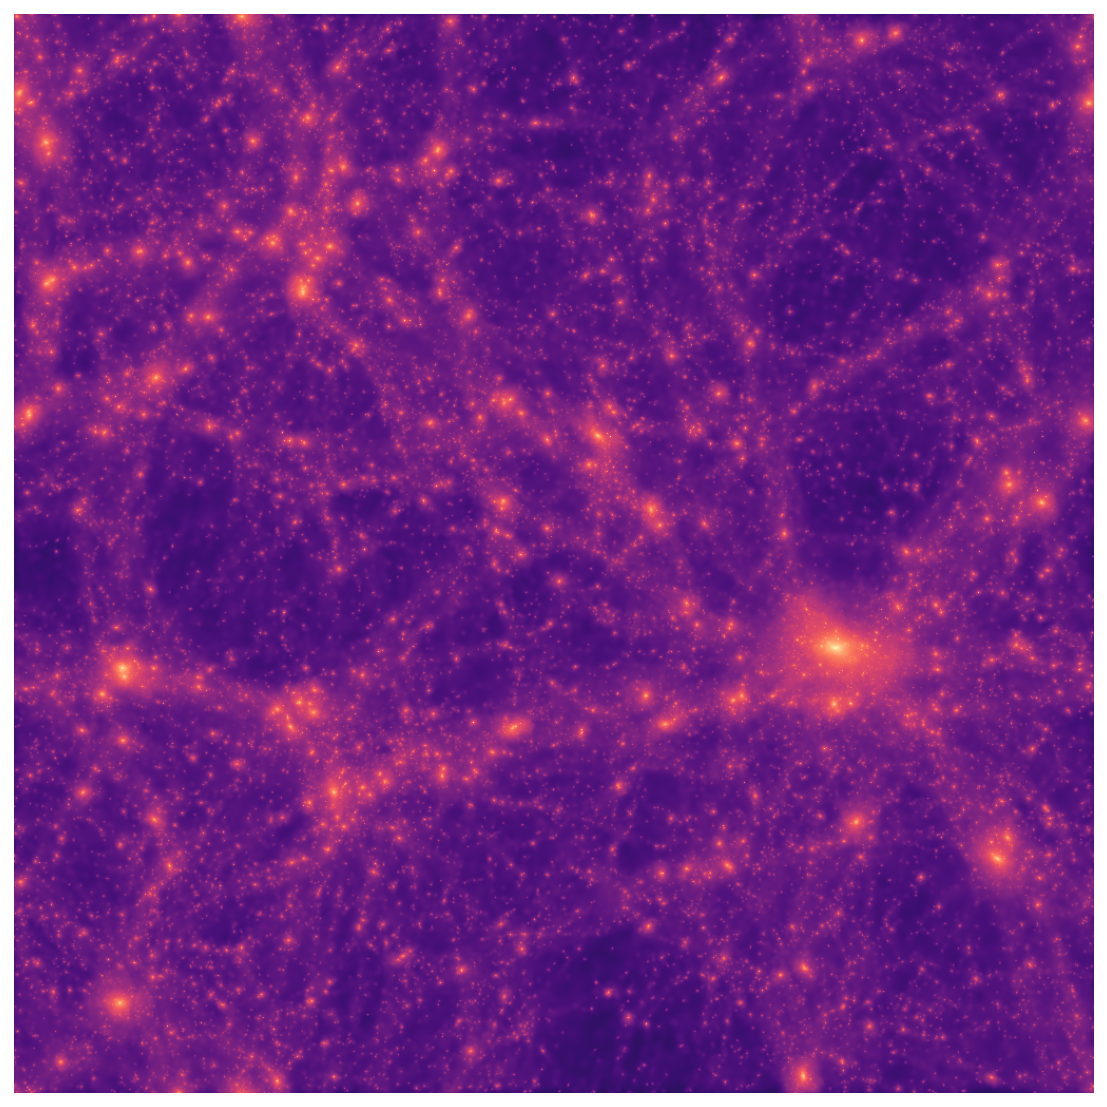

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

print("Preparing Periodic Panning Animation...")

# --- Animation Settings ---
n_frames = 120  # 4 seconds of video at 30 FPS
start_xc = 0.0
start_yc = Lbox / 2.0
start_zc = Lbox / 2.0

# --- Set up the Plot ---
# We remove all axes and margins to create a pure video frame
fig, ax = plt.subplots(figsize=(8, 8), dpi=135)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1)
ax.axis('off')

# Initialize an empty image. 
im = ax.imshow(np.zeros((512, 512)), cmap='magma', origin='lower', vmin=4.5, vmax=9)

# --- The Render Loop ---
def update(frame):
    # constant panning speed to show off the seamless wrap.
    t = frame / float(n_frames - 1)
    
    # Move the camera by 5 Box Lengths
    current_xc = start_xc + (t * 5*Lbox)

    # --- Project the Frame ---
    cam = sphviewer2.Camera(
        Lbox=Lbox,
        extent=Lbox,       # Lock the zoom to show the entire volume
        xc=current_xc,
        yc=start_yc,
        zc=start_zc,       
        azimuth=0.0,       
        r_min=4,
        r_max=10,          
        target_cells_per_h=4
    )
    
    proj = sphviewer2.Projector(cam)
    proj.project(parts, num_threads=8)
    image = proj.collapse()
    
    # Update the plot data
    im.set_data(np.log10(image + 1e-5))
    
    # Print progress
    if frame % 10 == 0:
        print(f"Rendered frame {frame} / {n_frames}")
        
    return [im]

# --- Generate and Save the Video ---
print("Rendering frames...")
ani = FuncAnimation(fig, update, frames=n_frames, blit=True)

# Export to an MP4 file using the h264 codec
video_filename = "wrap.mp4"
ani.save(video_filename, fps=30, extra_args=['-vcodec', 'libx264'])

print(f"\nSuccess! Wrapping animation saved as '{video_filename}'")